In [1]:
# This installs the optimized kernels for the M1-era architecture adapted for cloud GPUs.
!pip install unsloth
!pip install --no-deps xformers trl peft accelerate bitsandbytes

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.7/69.7 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.0 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 432.3/432.3 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.5/376.5 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.7/91

In [2]:
from unsloth import FastLanguageModel
import torch
import json
import pandas as pd
import re

# 1. Load Model (Optimized for Kaggle T4)
model_name = "unsloth/Llama-3.2-3B-Instruct"
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = model_name,
    max_seq_length = 2048,
    load_in_4bit = True,
)
# Fix the pad token warning
tokenizer.pad_token = tokenizer.eos_token 
FastLanguageModel.for_inference(model)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


2026-02-25 02:04:14.687968: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771985054.879108      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771985054.925420      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771985055.326552      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771985055.326587      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771985055.326590      24 computation_placer.cc:177] computation placer alr

🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.2.1: Fast Llama patching. Transformers: 4.57.6.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.35G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 3072, padding_idx=128004)
    (layers): ModuleList(
      (0): LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear4bit(in_features=3072, out_features=3072, bias=False)
          (k_proj): Linear4bit(in_features=3072, out_features=1024, bias=False)
          (v_proj): Linear4bit(in_features=3072, out_features=1024, bias=False)
          (o_proj): Linear4bit(in_features=3072, out_features=3072, bias=False)
          (rotary_emb): LlamaRotaryEmbedding()
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear4bit(in_features=3072, out_features=8192, bias=False)
          (up_proj): Linear4bit(in_features=3072, out_features=8192, bias=False)
          (down_proj): Linear4bit(in_features=8192, out_features=3072, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((3072,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNo

In [3]:
# --- Update in Step 3 (The Function) ---
def get_prediction(instruction):
    # messages = [
    #     {"role": "system", "content": "You are a smart home assistant. Classify instructions into one of these intents: light_on, light_off, ac_on, ac_off, vent_on, vent_off, fan_on, fan_off, heater_on, heater_off, multiplug_on, multiplug_off, tv_on, tv_off."},
    #     {"role": "user", "content": f"User says: \"{instruction}\"\n\nFormat your response exactly like this:\nReasoning: <one sentence logic>\nIntent: <label>"}
    # ]

    messages = [
        {
            "role": "system", 
            "content": (
                "You are an expert Home Automation Controller. Your task is to classify instructions "
                "into exactly one intent: light_on, light_off, ac_on, ac_off, vent_on, vent_off, "
                "fan_on, fan_off, heater_on, heater_off, multiplug_on, multiplug_off, tv_on, tv_off.\n\n"
                "### HIERARCHY OF LOGIC:\n"
                "1. EXPLICIT COMMANDS: If a device and state are named (e.g., 'turn off the AC'), "
                "select that intent (ac_off). Do NOT infer secondary needs (like turning on a heater).\n"
                "2. SYNONYMS: 'Dim' = light_off; 'Illuminate' = light_on; 'Low speed' = fan_off.\n"
                "3. CONSTRAINTS: Porch lights/lamps are 'light', not 'multiplug'. Never provide more than one label."
            )
        },
        {
            "role": "user", 
            "content": (
                f"User says: \"{instruction}\"\n\n"
                "Format your response exactly like this:\n"
                "Reasoning: <one sentence logic focusing on the explicit command>\n"
                "Intent: <single_label_only>"
            )
        }
    ]
    
    # tokenizer now creates the attention_mask automatically
    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt = True,
        return_tensors = "pt",
    ).to("cuda")

    outputs = model.generate(
        input_ids = inputs,
        # Add the attention mask here explicitly
        attention_mask = inputs.ne(tokenizer.pad_token_id).all(dim=0).unsqueeze(0) if hasattr(inputs, 'ne') else None,
        max_new_tokens = 64,
        temperature = 0.01,
        # Explicitly tell it which token to use for padding
        pad_token_id = tokenizer.eos_token_id
    )
    
    response = tokenizer.decode(outputs[0][len(inputs[0]):], skip_special_tokens=True)
    return response

In [4]:
# 3. Test on first 5 samples
input_file = "/kaggle/input/datasets/lochanbasyal/home-automation-intent-classification/intent_classification_reasoning_140.jsonl"
print(f"{'='*20} STARTING 5-SAMPLE TEST {'='*20}\n")

with open(input_file, 'r') as f:
    for i, line in enumerate(f):
        if i >= 5: break # Stop after 5 samples
        
        data = json.loads(line)
        instruction = data['instruction']
        ground_truth = data['intent']
        
        print(f"SAMPLE #{i+1}")
        print(f"Instruction: {instruction}")
        print(f"Ground Truth: {ground_truth}")
        
        raw_output = get_prediction(instruction)
        
        print(f"Model Output:\n{raw_output}")
        print(f"{'-'*50}\n")

print(f"{'='*20} TEST COMPLETE {'='*20}")

==================== STARTING 5-SAMPLE TEST ====================

SAMPLE #1
Instruction: Turn on the lights in the bedroom.
Ground Truth: light_on
Model Output:
Reasoning: The explicit command "Turn on the lights in the bedroom" directly implies the intent to activate the lighting system.
Intent: light_on
--------------------------------------------------

SAMPLE #2
Instruction: Please switch on the lights in the living room.
Ground Truth: light_on
Model Output:
Reasoning: The explicit command "switch on the lights" implies turning the lights on.
Intent: light_on
--------------------------------------------------

SAMPLE #3
Instruction: It's a bit dark here, can you illuminate the room?
Ground Truth: light_on
Model Output:
Reasoning: The explicit command "illuminate the room" directly implies the intent to turn on the lights.
Intent: light_on
--------------------------------------------------

SAMPLE #4
Instruction: Turn on the lights, I need better visibility.
Ground Truth: light_on
M

In [5]:
# 4. Test on all samples
print(f"{'='*20} STARTING ALL SAMPLE TEST {'='*20}\n")

with open(input_file, 'r') as f:
    for i, line in enumerate(f):
        # if i >= 5: break # Stop after 5 samples
        
        data = json.loads(line)
        instruction = data['instruction']
        ground_truth = data['intent']
        
        print(f"SAMPLE #{i+1}")
        print(f"Instruction: {instruction}")
        print(f"Ground Truth: {ground_truth}")
        
        raw_output = get_prediction(instruction)
        
        print(f"Model Output:\n{raw_output}")
        print(f"{'-'*50}\n")

print(f"{'='*20} TEST COMPLETE {'='*20}")

==================== STARTING ALL SAMPLE TEST ====================

SAMPLE #1
Instruction: Turn on the lights in the bedroom.
Ground Truth: light_on
Model Output:
Reasoning: The explicit command "Turn on the lights in the bedroom" directly implies the intent to activate the lighting system.
Intent: light_on
--------------------------------------------------

SAMPLE #2
Instruction: Please switch on the lights in the living room.
Ground Truth: light_on
Model Output:
Reasoning: The explicit command is to switch on the lights in the living room, which implies turning on the lights.
Intent: light_on
--------------------------------------------------

SAMPLE #3
Instruction: It's a bit dark here, can you illuminate the room?
Ground Truth: light_on
Model Output:
Reasoning: The explicit command "illuminate the room" directly implies the need to turn on the lights.
Intent: light_on
--------------------------------------------------

SAMPLE #4
Instruction: Turn on the lights, I need better visibi

==================== STARTING FULL EVALUATION ====================

Processed 10 samples...
Processed 20 samples...
Processed 30 samples...
Processed 40 samples...
Processed 50 samples...
Processed 60 samples...
Processed 70 samples...
Processed 80 samples...
Processed 90 samples...
Processed 100 samples...
Processed 110 samples...
Processed 120 samples...
Processed 130 samples...
Processed 140 samples...

==================== FINAL METRICS ====================
Overall Accuracy: 98.57%
Weighted F1-Score: 0.9857

Classification Report:
                precision    recall  f1-score   support

       ac_off       1.00      0.90      0.95        10
        ac_on       0.91      1.00      0.95        10
      fan_off       1.00      1.00      1.00        11
       fan_on       1.00      1.00      1.00         9
   heater_off       1.00      0.90      0.95        10
    heater_on       0.91      1.00      0.95        10
    light_off       1.00      1.00      1.00        10
     light_on    

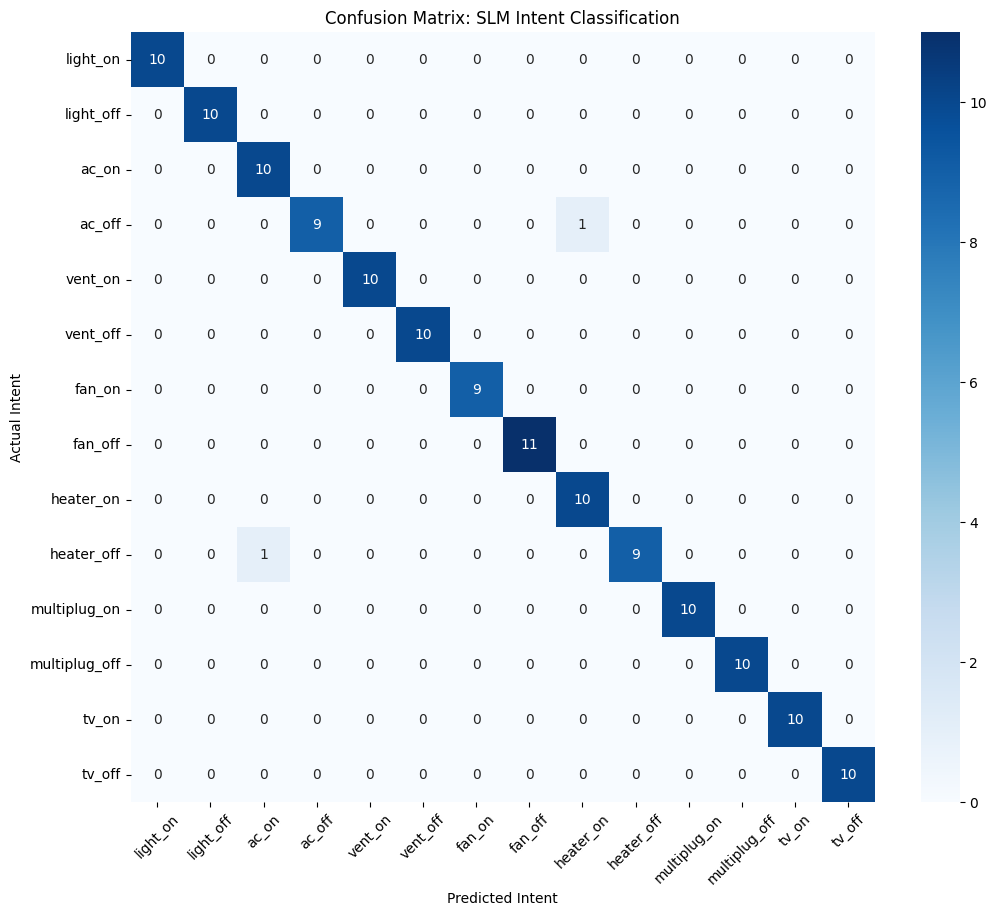

In [6]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# 1. Configuration
labels = [
    "light_on", "light_off", "ac_on", "ac_off", "vent_on", "vent_off", 
    "fan_on", "fan_off", "heater_on", "heater_off", "multiplug_on", 
    "multiplug_off", "tv_on", "tv_off"
]

results = []

print(f"{'='*20} STARTING FULL EVALUATION {'='*20}\n")

# 2. Run Inference
with open(input_file, 'r') as f:
    for i, line in enumerate(f):
        data = json.loads(line)
        instruction = data['instruction'] # Defined for use in get_prediction
        
        # Get the raw model response
        raw_output = get_prediction(instruction) # FIXED: Use local 'instruction'
        
        # --- PARSING LOGIC ---
        predicted_intent = "format_error"
        if "Intent:" in raw_output:
            # Extract label safely
            predicted_intent = raw_output.split("Intent:")[-1].strip().lower().split()[0].replace(".", "").replace(",", "")

        results.append({
            "instruction": instruction,
            "ground_truth_intent": data['intent'].strip().lower(),
            "ground_truth_reasoning": data.get('reasoning', 'N/A'),
            "predicted_intent": predicted_intent, # FIXED: Variable name
            "model_reasoning": raw_output.split("Intent:")[0].replace("Reasoning:", "").strip()
        })
        
        if (i+1) % 10 == 0:
            print(f"Processed {i+1} samples...")

# 3. Create DataFrame and Calculate Metrics
df_eval = pd.DataFrame(results)
y_true = df_eval['ground_truth_intent']
y_pred = df_eval['predicted_intent']

print(f"\n{'='*20} FINAL METRICS {'='*20}")
print(f"Overall Accuracy: {accuracy_score(y_true, y_pred) * 100:.2f}%")
print(f"Weighted F1-Score: {f1_score(y_true, y_pred, average='weighted'):.4f}")
print(f"\nClassification Report:\n", classification_report(y_true, y_pred))

# 4. Print Misclassified Instructions (Your Request)
print(f"\n{'='*20} MISCLASSIFIED SAMPLES REPORT {'='*20}\n")
misclassified = df_eval[df_eval['ground_truth_intent'] != df_eval['predicted_intent']]

for idx, row in misclassified.iterrows():
    print(f"Instruction         : {row['instruction']}")
    print(f"Ground Truth Intent : {row['ground_truth_intent']}")
    print(f"Ground Truth Logic  : {row['ground_truth_reasoning']}")
    print(f"Model Predicted     : {row['predicted_intent']}")
    print(f"Model Reasoning     : {row['model_reasoning']}")
    print(f"{'-'*70}\n")

# 5. Generate and Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred, labels=labels)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix: SLM Intent Classification')
plt.ylabel('Actual Intent')
plt.xlabel('Predicted Intent')
plt.xticks(rotation=45)
plt.show()

# Save results
df_eval.to_csv("final_evaluation_metrics.csv", index=False)